In [ ]:
# Exercise
# Load the counties and ward data
# Using a spatial join, summarize the total population by county. What county has the highest population? What about the lowest? Note that there are many wards that extend over county boundaries.
# Create a map to show population information by census area, with the county boundaries plotted overtop of the chloropleth map.

In [ ]:
# 1. import python libraries

In [ ]:
# GeoPandas (gpd) → loads and handles spatial data
# Matplotlib (plt) → draws the map
# Cartopy (ccrs, cfeature) → controls map projection + background features
# ShapelyFeature → connects your data to the map

In [9]:
import geopandas as gpd # for working with maps and spatial data (shapefiles, boundaries, points). Let's you treat map data like a table but with geometry
import matplotlib.pyplot as plt # plotting library. pyplot part used to draw charts and maps to visually display data
import matplotlib.patches as mpatches # tool for customising legends, map symbols and coloured legend boxes
import matplotlib.lines as mlines # tool for creating line symbols for boundaries
import cartopy.crs as ccrs # cartopy handles map projections. coordinate reference system (CRS) aligns coordinate systems of different datasets
import cartopy.feature as cfeature # provides ready-made map features like coastlines, borders, land, oceans
from cartopy.feature import ShapelyFeature # takes shapes from GeoPandas or Shapely and adds them onto a Cartopy map

In [ ]:
# 2. Load data, inspect data, check columns, verify geometry exists

In [10]:
counties = gpd.read_file("data_files/Counties.shp") # read counties shapefile into a GeoPandas spatial data file and store in variable 'counties'
wards = gpd.read_file("data_files/NI_Wards.shp") # read wards shapefile into a GeoPandas spatial data file and store in variable 'wards'

print(counties.head()) # print first 5 rows to inspect data for column names, data types, geometry
print(wards.head()) # print first 5 rows to check what columns exist, whether population data is included, and whether geometry loaded correctly
print(wards.columns) # print column names to determine which column stores population, which column stores names, and what fields are available for analysis

   COUNTY_ID   CountyName    Area_SqKM  OBJECTID  \
0          6       TYRONE  3265.796622         1   
1          1       ANTRIM  3097.847750         2   
2          2       ARMAGH  1327.228438         3   
3          4    FERMANAGH  1850.832538         4   
4          5  LONDONDERRY  2118.316853         5   

                                            geometry  
0  POLYGON ((-7.38177 54.94208, -7.3817 54.94201,...  
1  MULTIPOLYGON (((-5.95296 54.55222, -5.95298 54...  
2  POLYGON ((-6.35398 54.50927, -6.35191 54.50891...  
3  POLYGON ((-7.69417 54.60511, -7.6939 54.60498,...  
4  POLYGON ((-6.66919 55.19899, -6.66918 55.19893...  
  Ward Code          Ward  Population  \
0    95DD05     Ballykeel        1739   
1    95DD06  Ballyloughan        2588   
2    95DD03      Ardeevin        3503   
3    95DD04        Ballee        1926   
4    95DD09  Craigywarren        2590   

                                            geometry  
0  POLYGON ((-6.25014 54.85879, -6.25015 54.85875...  


In [ ]:
# 3. Align coordinate reference systems

In [11]:
if counties.crs != wards.crs: # use a conditional statement to query if the CRS for the counties dataset is the same as the CRS for the wards dataset
    counties = counties.to_crs(wards.crs) # if CRS are different python enters if block and reprojects the counties dataset to the CRS of wards

print("CRS match:", counties.crs == wards.crs) # boolean checks if the CRS for the two datasets now match

CRS match: True


In [ ]:
# 4. Join datasets using a spatial join

# a spatial join combines datasets based on location, matching rows based on where shapes are on the map

In [12]:
joined = gpd.sjoin( # sjoin queries which map features overlap or touch each other
    wards, # left dataset containing features to be retained
    counties, # right dataset providing the county information to attach
    how="inner", # join type used is 'inner' which keeps rows where a match exists
    predicate="intersects" # spatial rule that matches features that touch or overlap
)

# the join results in a new GeoDataFrame names 'joined' containing ward data, county data, and geometry

print(joined.head()) # show the first 5 rows to inspect whether the join worked and if county names were added
print(joined.columns) # show all available columns to check county name field and population field

  Ward Code          Ward  Population  \
0    95DD05     Ballykeel        1739   
1    95DD06  Ballyloughan        2588   
2    95DD03      Ardeevin        3503   
3    95DD04        Ballee        1926   
4    95DD09  Craigywarren        2590   

                                            geometry  index_right  COUNTY_ID  \
0  POLYGON ((-6.25014 54.85879, -6.25015 54.85875...            1          1   
1  POLYGON ((-6.28913 54.86946, -6.28917 54.86949...            1          1   
2  POLYGON ((-6.29527 54.84752, -6.29527 54.84751...            1          1   
3  POLYGON ((-6.26087 54.84528, -6.26096 54.84524...            1          1   
4  POLYGON ((-6.24807 54.89652, -6.24819 54.89645...            1          1   

  CountyName   Area_SqKM  OBJECTID  
0     ANTRIM  3097.84775         2  
1     ANTRIM  3097.84775         2  
2     ANTRIM  3097.84775         2  
3     ANTRIM  3097.84775         2  
4     ANTRIM  3097.84775         2  
Index(['Ward Code', 'Ward', 'Population', 'geometr

In [5]:
print(wards.columns) # check population column name

Index(['Ward Code', 'Ward', 'Population', 'geometry'], dtype='str')


In [ ]:
# 5. Analysis: summarise population by county

In [13]:
population_by_county = joined.groupby("CountyName")["Population"].sum() 
# use aggregation to group wards by county and calculate the sum total population for each county group

print("\nPopulation by county:") # output heading
print(population_by_county.sort_values(ascending=False)) # print results and sort counties from the highest population to the lowest population

highest = population_by_county.idxmax() # returns the label of the maximum value
lowest = population_by_county.idxmin() # returns the label of the smallest value

# an f-string lets you insert variables into text
print(f"\nCounty with highest population: {highest} ({population_by_county.max():,.0f})") 
# use an f-string to print the county with the highest population with appropriate number formatting

print(f"County with lowest population: {lowest} ({population_by_county.min():,.0f})")
# use an f-string to print the county with the lowest population with appropriate number formatting


Population by county:
CountyName
ANTRIM         718369
DOWN           639915
LONDONDERRY    293296
TYRONE         253986
ARMAGH         232505
FERMANAGH       75906
Name: Population, dtype: int64

County with highest population: ANTRIM (718,369)
County with lowest population: FERMANAGH (75,906)


In [ ]:
# 6. Create chloropleth map of ward population

# a chloropleth map colours areas according to a value

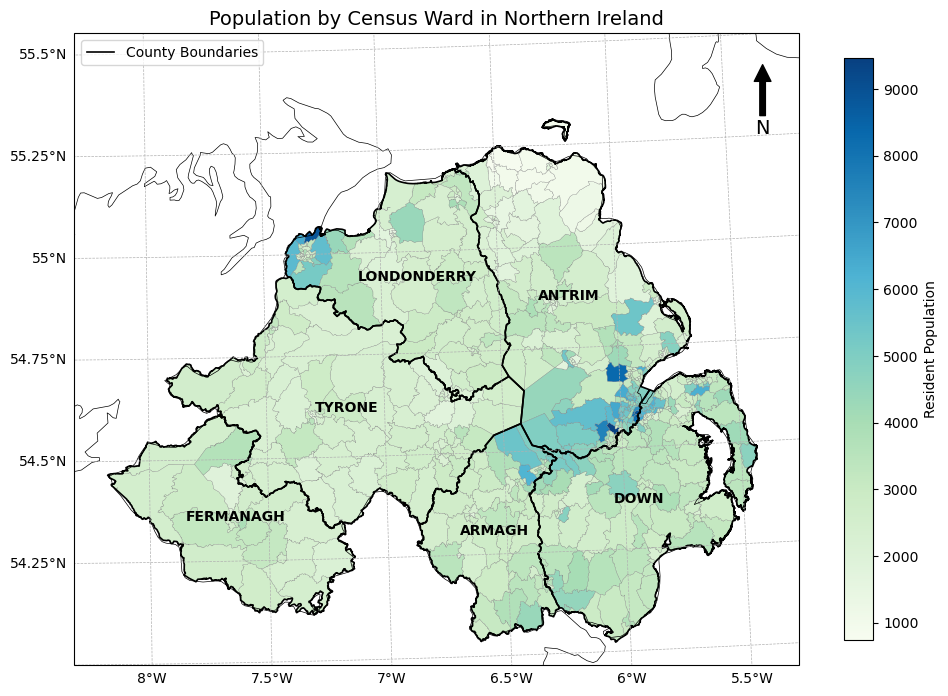

In [15]:
# A. Set the map projection
map_crs = ccrs.UTM(29) # set the map projection to UTM Zone 29

# other options:
# EPSG:29902 Irish Grid
# EPSG:2157 Irish Transverse Mercator

# B. Reproject the data
# convert layers into the same CRS
wards_utm = wards.to_crs("EPSG:32629") 
counties_utm = counties.to_crs("EPSG:32629") 

# C. Create the figure and map axis
fig, ax = plt.subplots(
    1,
    1,
    figsize=(10, 10), # creates a 10 x 10 inch map
    subplot_kw={"projection": map_crs}
)

# D. Plot the ward population choropleth
wards_utm.plot(
    ax=ax,
    column="Population", # colour wards by population
    cmap="GnBu", # use orange-red colours
    legend=True, # show a colour legend
    edgecolor="grey", # draw ward outlines in grey
    linewidth=0.2, # make ward outlines thin
    transform=map_crs,
    legend_kwds={
        "label": "Resident Population",
        "shrink": 0.6 # add the legend label
    }
)

# E. Plot county boundaries on top
counties_utm.boundary.plot(
    ax=ax,
    edgecolor="black",
    linewidth=1.2,
    transform=map_crs
)

# F. Add county names
for idx, row in counties_utm.iterrows():

    # Get centre point of each county
    centroid = row.geometry.centroid

    # Add text label
    ax.text(
        centroid.x,
        centroid.y,
        row["CountyName"],   # replace with your actual county name field if needed
        fontsize=10,
        fontweight='bold',
        ha='center',
        transform=map_crs
    )
    
# G. Create legend item for county boundaries
county_line = mlines.Line2D(
    [],
    [],
    color='black',
    linewidth=1.2,
    label='County Boundaries'
)

ax.legend(
    handles=[county_line],
    loc='upper left' # add legend
)

# H. Add map background reference features (coastlines and borders)
ax.add_feature(cfeature.COASTLINE, linewidth=0.5)
ax.add_feature(cfeature.BORDERS, linewidth=0.5)

# I. Set the map extent around Northern Ireland
ax.set_extent([-8.3, -5.3, 54.0, 55.5], crs=ccrs.PlateCarree()) # zooms the map to NI

# J. Add latitude and longitude gridlines
gridlines = ax.gridlines(
    draw_labels=True,
    linewidth=0.5,
    linestyle="--"
)

# K. Add north arrow
ax.annotate(
    'N',
    xy=(0.95, 0.95),          # arrow tip
    xytext=(0.95, 0.85),      # position of N text
    arrowprops=dict(
        facecolor='black',
        width=4,
        headwidth=12
    ),
    ha='center',
    va='center',
    fontsize=14,
    xycoords=ax.transAxes
)

# L. Remove labels from the top and right side, so the map looks cleaner
gridlines.top_labels = False
gridlines.right_labels = False

# M. Add title and display map
plt.title("Population by Census Ward in Northern Ireland", fontsize=14)

plt.tight_layout()
plt.show()